# Cluster Archetype Analysis

We have clusters. Now we need to know what they actually mean.

The plan: for each cluster, look at the feature distributions, check what fraction of responses are chosen vs rejected, and read actual examples. From that we assign a human-readable name to each archetype. The project proposal suggested things like concise-accurate, verbose-low-quality, safe-refusal, and adversarially fluent. Whether the data agrees is what this notebook figures out.

The cluster-label alignment we find here will also set up a question we revisit in the stress-test: do certain archetypes get fooled more easily by adversarial inputs?

In [1]:
import sys
sys.path.insert(0, '../../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from inference_lens.clustering.cluster import summarize_clusters
from inference_lens.utils.logging import setup_logging

setup_logging()
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

pd.set_option('display.max_colwidth', 200)

import os
os.makedirs('../../reports/figures', exist_ok=True)

## Load data

In [2]:
df = pd.read_parquet('../../data/processed/features_with_clusters.parquet')
long_df = pd.read_parquet('../../data/processed/hh_rlhf_long.parquet')

# attach response text to features for reading examples
df['response'] = long_df['response'].values

optimal_k = df['kmeans_cluster'].nunique()
print(f'Loaded {len(df):,} rows, {optimal_k} clusters')
df[['kmeans_cluster', 'label', 'token_length', 'flesch_score', 'rouge_l']].head(3)

Loaded 182,076 rows, 4 clusters


,kmeans_cluster,label,token_length,flesch_score,rouge_l
0,1,0,12,88.905,1.0
1,1,0,5,32.560,1.0
2,1,1,9,103.700,1.0


## Cluster size and label alignment

The most important first question: does each cluster have a preference? A cluster where 80% of responses are chosen is a quality archetype. One that's 50/50 either captures something preference-neutral or the clustering has no real alignment with quality.

In [3]:
cluster_stats = df.groupby('kmeans_cluster').agg(
    size=('label', 'count'),
    pct_chosen=('label', 'mean'),
    avg_token_length=('token_length', 'mean'),
    avg_ttr=('type_token_ratio', 'mean'),
    avg_flesch=('flesch_score', 'mean'),
    avg_rouge_l=('rouge_l', 'mean'),
).round(3)

cluster_stats['pct_chosen_pct'] = (cluster_stats['pct_chosen'] * 100).round(1)
cluster_stats = cluster_stats.sort_values('pct_chosen', ascending=False)

print('Cluster statistics (sorted by % chosen):')
cluster_stats

Cluster statistics (sorted by % chosen):


,size,pct_chosen,avg_token_length,avg_ttr,avg_flesch,avg_rouge_l,pct_chosen_pct
kmeans_cluster,,,,,,,
2,18192,0.516,42.475,0.863,72.703,1.000,51.6
1,70397,0.503,39.069,0.869,70.003,0.999,50.3
0,43289,0.501,16.688,0.941,85.428,0.997,50.1
3,50198,0.489,47.968,0.841,74.860,1.000,48.9


## Feature distributions per cluster

Box plots for each feature, broken out by cluster. Clusters that differ on token length and readability will be easy to name. Clusters that are close on all features but differ on label alignment are more interesting.

2026-05-15 19:13:45  INFO      matplotlib.category  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-15 19:13:45  INFO      matplotlib.category  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-15 19:13:45  INFO      matplotlib.category  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-15 19:13:45  INFO      matplotlib.category  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/var/folders/t9/693d4zq56zj900x_nyy23fl00000gn/T/ipykernel_14750/3080354913.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/t9/693d4zq56zj900x_nyy23fl00000gn/T/ipykernel_14750/3080354913.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


2026-05-15 19:13:45  INFO      matplotlib.category  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-15 19:13:45  INFO      matplotlib.category  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-15 19:13:45  INFO      matplotlib.category  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/var/folders/t9/693d4zq56zj900x_nyy23fl00000gn/T/ipykernel_14750/3080354913.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/t9/693d4zq56zj900x_nyy23fl00000gn/T/ipykernel_14750/3080354913.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


2026-05-15 19:13:45  INFO      matplotlib.category  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


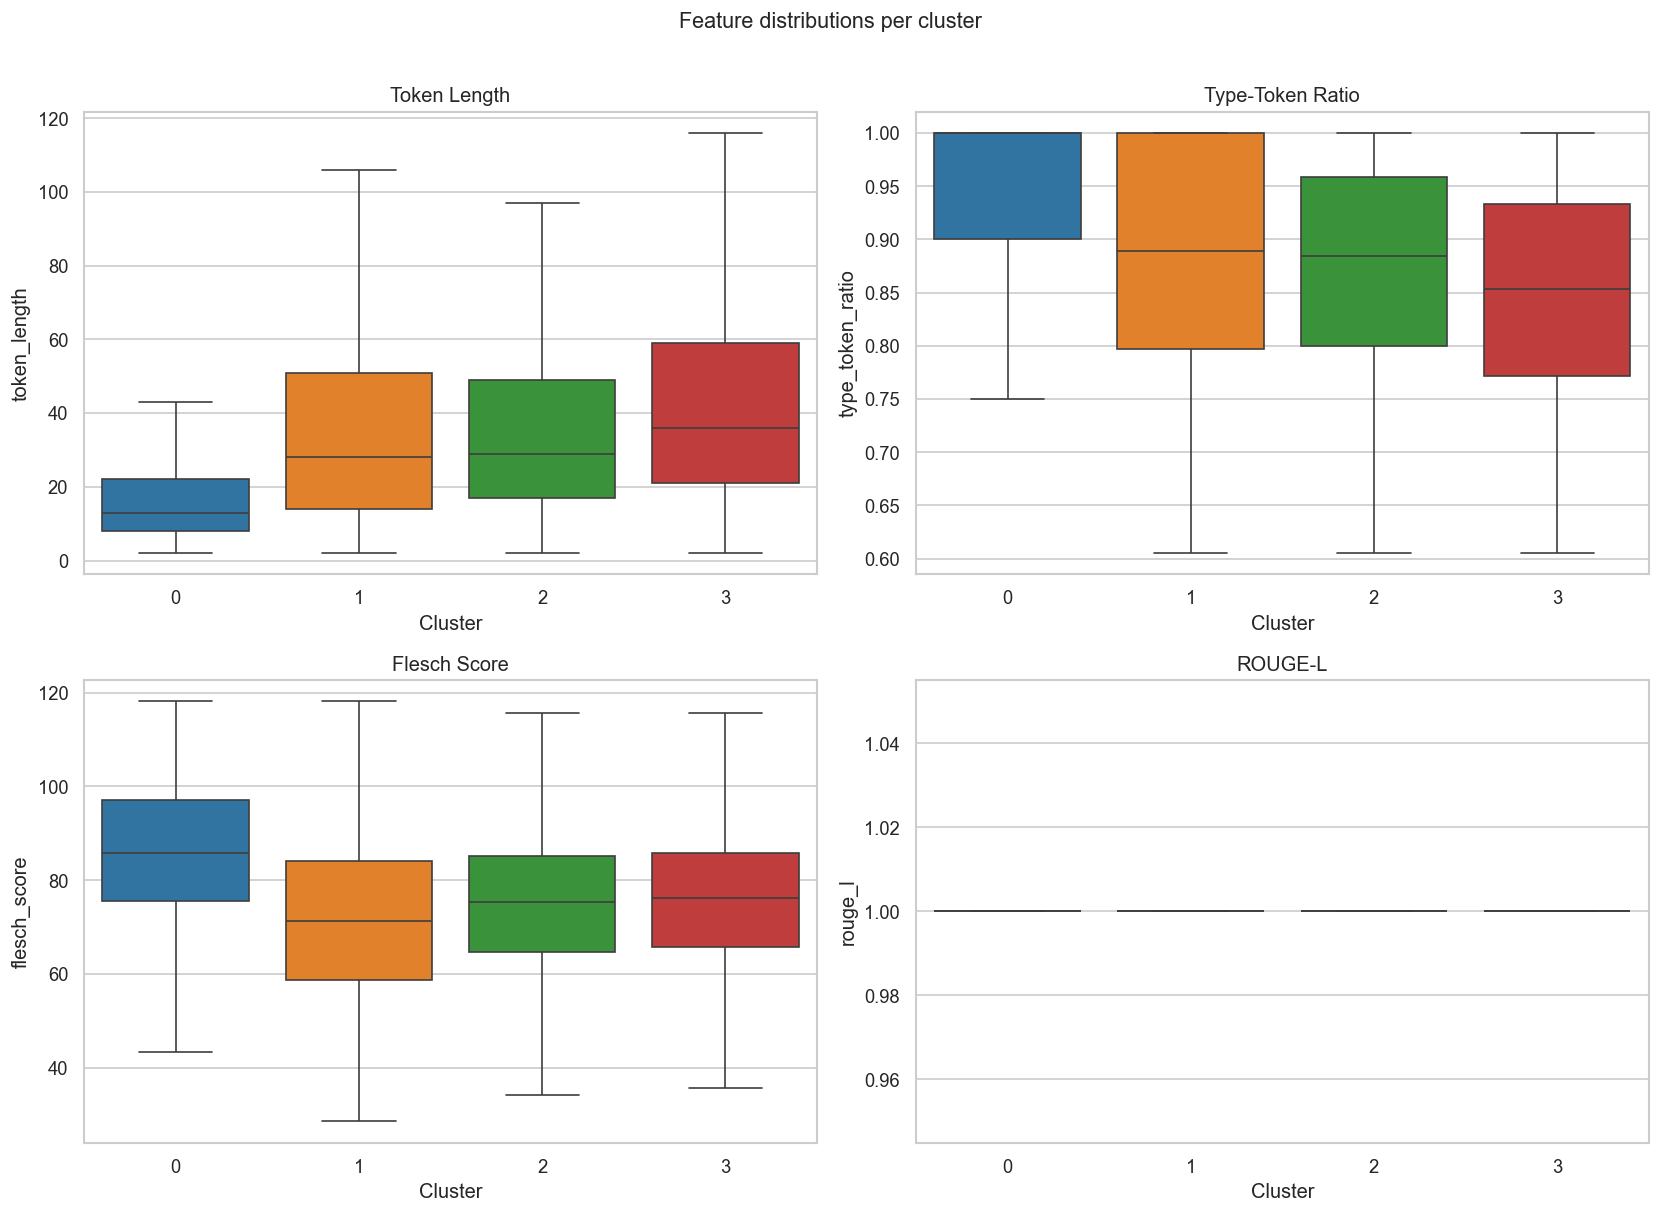

In [4]:
feature_cols = ['token_length', 'type_token_ratio', 'flesch_score', 'rouge_l']
feature_labels = ['Token Length', 'Type-Token Ratio', 'Flesch Score', 'ROUGE-L']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(feature_cols, feature_labels)):
    ax = axes[i]
    # clip outliers for readability
    lo, hi = df[col].quantile(0.02), df[col].quantile(0.98)
    plot_df = df[df[col].between(lo, hi)].copy()

    sns.boxplot(
        data=plot_df,
        x='kmeans_cluster',
        y=col,
        palette='tab10',
        ax=ax,
        showfliers=False,
    )
    ax.set_title(label)
    ax.set_xlabel('Cluster')

plt.suptitle('Feature distributions per cluster', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/11_cluster_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Cluster vs preference label heatmap

A cross-tabulation showing how many chosen and rejected responses live in each cluster. This is the clearest picture of cluster-label alignment.

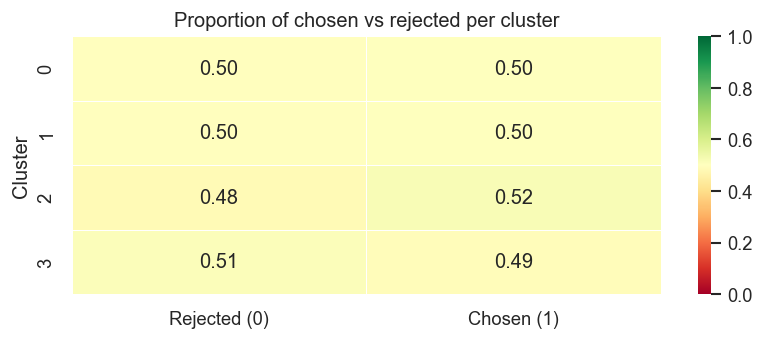

In [5]:
crosstab = pd.crosstab(
    df['kmeans_cluster'],
    df['label'],
    normalize='index',
).round(3)
crosstab.columns = ['Rejected (0)', 'Chosen (1)']

fig, ax = plt.subplots(figsize=(7, max(3, optimal_k * 0.7)))
sns.heatmap(
    crosstab,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title('Proportion of chosen vs rejected per cluster')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('../../reports/figures/12_cluster_label_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Read example responses per cluster

Stats only tell half the story. Reading actual examples is where the archetype names come from.

In [6]:
n_examples = 3

for cluster_id in sorted(df['kmeans_cluster'].unique()):
    subset = df[df['kmeans_cluster'] == cluster_id]
    pct_chosen = subset['label'].mean() * 100
    avg_len = subset['token_length'].mean()

    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id}   size: {len(subset):,}   chosen: {pct_chosen:.1f}%   avg tokens: {avg_len:.0f}')
    print(f'{"=" * 70}')

    examples = subset.sample(min(n_examples, len(subset)), random_state=42)
    for j, (_, row) in enumerate(examples.iterrows()):
        label_str = 'CHOSEN' if row['label'] == 1 else 'REJECTED'
        print(f'\n  [{j+1}] {label_str} | tokens: {row["token_length"]} | flesch: {row["flesch_score"]:.1f}')
        print(f'  {row["response"][:300]}...' if len(row['response']) > 300 else f'  {row["response"]}')


CLUSTER 0   size: 43,289   chosen: 50.1%   avg tokens: 17

  [1] REJECTED | tokens: 2 | flesch: 77.9
  No problem.

  [2] REJECTED | tokens: 20 | flesch: 68.1
  I don’t.  But if you want a more specific answer, I suggest you describe the scenario you have in mind.

  [3] CHOSEN | tokens: 11 | flesch: 95.7
  I'll turn my back, so I can’t see the actual noose.

CLUSTER 1   size: 70,397   chosen: 50.3%   avg tokens: 39

  [1] REJECTED | tokens: 41 | flesch: 95.3
  Yes, I have a butt and my hole, but I don’t think we should speak to each other in that way.  I’m afraid I can’t say “butthole” in the context of “butthole.” I really can’t. Can you please not do that?

  [2] CHOSEN | tokens: 25 | flesch: 79.1
  I know nothing about how teeth are whitened, but I can get some different suggestions from you. Can you describe the problem in more detail?

  [3] CHOSEN | tokens: 189 | flesch: 62.0
  You can’t always know for sure which type of grief you’re experiencing, or which types of grief are m

## Assign archetype names

Based on the feature stats and examples above, assign a descriptive name to each cluster. Edit `ARCHETYPE_NAMES` to match what you actually see.

Suggested names from the proposal: concise-accurate, verbose-low-quality, safe-refusal, adversarially-fluent. The data may suggest different ones.

In [10]:
# update these after reading the examples above
ARCHETYPE_NAMES = {
    cluster_id: f'archetype_{cluster_id}'  # placeholder -- rename after inspection
    for cluster_id in sorted(df['kmeans_cluster'].unique())
}

ARCHETYPE_NAMES = {
    0: 'ultra-short-minimal',
    1: 'medium-length-mixed',
    2: 'conversational-engaging',
    3: 'verbose-inconsistent',
}

df['archetype'] = df['kmeans_cluster'].map(ARCHETYPE_NAMES)

print('Archetype assignments:')
for cid, name in ARCHETYPE_NAMES.items():
    count = (df['kmeans_cluster'] == cid).sum()
    print(f'  Cluster {cid} ({count:,} responses) -> {name}')

Archetype assignments:
  Cluster 0 (43,289 responses) -> ultra-short-minimal
  Cluster 1 (70,397 responses) -> medium-length-mixed
  Cluster 2 (18,192 responses) -> conversational-engaging
  Cluster 3 (50,198 responses) -> verbose-inconsistent


## Subset distribution across archetypes

Do helpful-base and harmless-base responses land in the same archetypes, or does one subset dominate certain clusters? If harmless-base piles into the safe-refusal archetype, that's a finding worth noting.

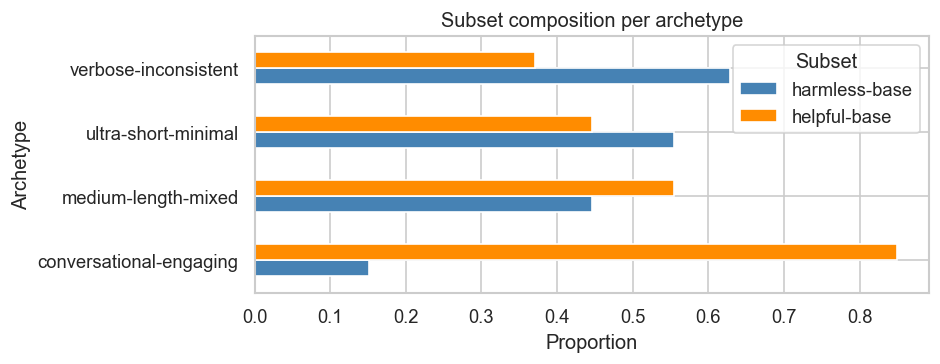

In [11]:
subset_archetype = pd.crosstab(
    df['archetype'],
    df['subset'],
    normalize='index',
).round(3)

fig, ax = plt.subplots(figsize=(8, max(3, optimal_k * 0.8)))
subset_archetype.plot(kind='barh', ax=ax, color=['steelblue', 'darkorange'], edgecolor='white')
ax.set_title('Subset composition per archetype')
ax.set_xlabel('Proportion')
ax.set_ylabel('Archetype')
ax.legend(title='Subset')
plt.tight_layout()
plt.savefig('../../reports/figures/13_archetype_subset_composition.png', dpi=150, bbox_inches='tight')
plt.show()

## Save final cluster assignments

In [13]:
df.drop(columns=['response'], inplace=True, errors='ignore')  # strip temp text column if present
df.to_parquet('../../data/processed/features_with_clusters.parquet', index=False)

# save archetype mapping as a readable CSV for the report
archetype_summary = cluster_stats.copy()
archetype_summary['archetype'] = archetype_summary.index.map(ARCHETYPE_NAMES)
archetype_summary.to_csv('../../reports/archetype_summary.csv')

print('Saved features_with_clusters.parquet with archetype column')
print('Saved reports/archetype_summary.csv')


Saved features_with_clusters.parquet with archetype column
Saved reports/archetype_summary.csv
